# 1) Convert DATE column to datetime

Convert the non-standard date format like `January-92` into a proper datetime type using `datetime.strptime("%B-%y")`.


In [1]:
import pandas as pd
from datetime import datetime

df = pd.read_csv("Alcohol_Sales.csv")

df["date"] = df["DATE"].apply(lambda x: datetime.strptime(x, "%B-%y"))

df.head()


,DATE,units_sold,date
0,January-92,3459,1992-01-01
1,February-92,3458,1992-02-01
2,March-92,4002,1992-03-01
3,April-92,4564,1992-04-01
4,May-92,4221,1992-05-01


# 2) Set date as index and plot the time series

We set the `date` column as the DataFrame index and visualize the trend of `units_sold` over time.


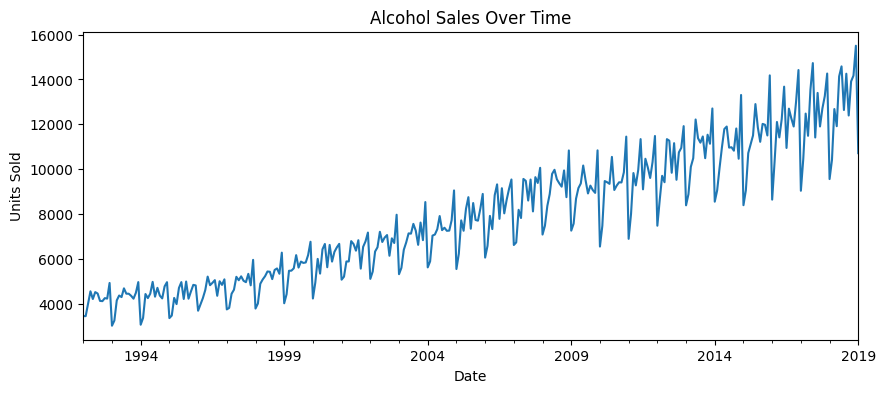

In [2]:
import matplotlib.pyplot as plt

df = df.set_index("date")

df["units_sold"].plot(figsize=(10, 4), title="Alcohol Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()


# 3) Apply shift to create lag features

Use the `shift()` function to create a new column that shows the previous month's sales.  
This helps compare the current month with the previous one.


In [3]:
# Create a new column showing the previous month's sales
df["Prev_Month_Sales"] = df["units_sold"].shift(1)

df.head()


,DATE,units_sold,Prev_Month_Sales
date,,,
1992-01-01,January-92,3459,NaN
1992-02-01,February-92,3458,3459.0
1992-03-01,March-92,4002,3458.0
1992-04-01,April-92,4564,4002.0
1992-05-01,May-92,4221,4564.0


# 4) Apply differencing to remove trend

Use differencing to calculate how much sales changed compared to the previous month.  
This helps stabilize the time series and remove trends.


In [4]:
# Calculate the difference from the previous month
df["Monthly_Change"] = df["units_sold"].diff()

df.head()


,DATE,units_sold,Prev_Month_Sales,Monthly_Change
date,,,,
1992-01-01,January-92,3459,NaN,NaN
1992-02-01,February-92,3458,3459.0,-1.0
1992-03-01,March-92,4002,3458.0,544.0
1992-04-01,April-92,4564,4002.0,562.0
1992-05-01,May-92,4221,4564.0,-343.0


# 5) Plot the differenced series

Plot the `Monthly_Change` column to visualize how sales fluctuate from month to month.


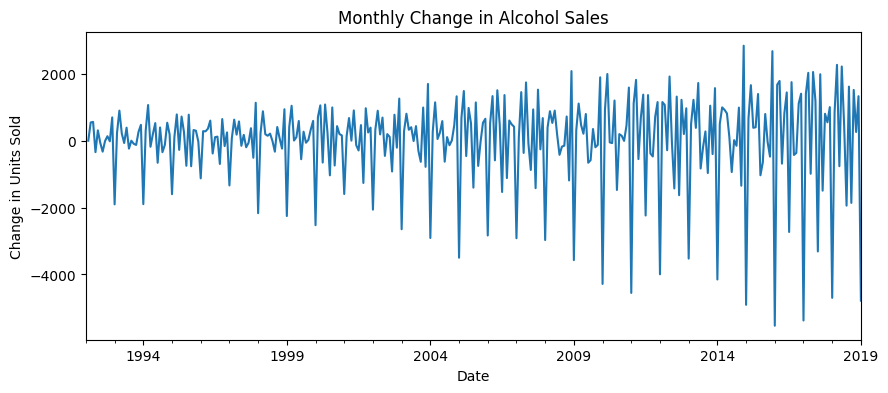

In [5]:
df["Monthly_Change"].plot(figsize=(10, 4), title="Monthly Change in Alcohol Sales")
plt.xlabel("Date")
plt.ylabel("Change in Units Sold")
plt.show()


# 6) Apply seasonal differencing

Perform seasonal differencing to remove yearly seasonality.  
Since the data is monthly, we use a lag of 12.


In [6]:
# Seasonal differencing with a 12-month lag
df["Seasonal_Diff"] = df["units_sold"].diff(12)

df.head(15)


,DATE,units_sold,Prev_Month_Sales,Monthly_Change,Seasonal_Diff
date,,,,,
1992-01-01,January-92,3459,NaN,NaN,NaN
1992-02-01,February-92,3458,3459.0,-1.0,NaN
1992-03-01,March-92,4002,3458.0,544.0,NaN
1992-04-01,April-92,4564,4002.0,562.0,NaN
1992-05-01,May-92,4221,4564.0,-343.0,NaN
1992-06-01,June-92,4529,4221.0,308.0,NaN
1992-07-01,July-92,4466,4529.0,-63.0,NaN
1992-08-01,August-92,4137,4466.0,-329.0,NaN
1992-09-01,September-92,4126,4137.0,-11.0,NaN


# 7) Plot the seasonal differenced series

Plot the `Seasonal_Diff` column to visualize yearly seasonal changes in alcohol sales.


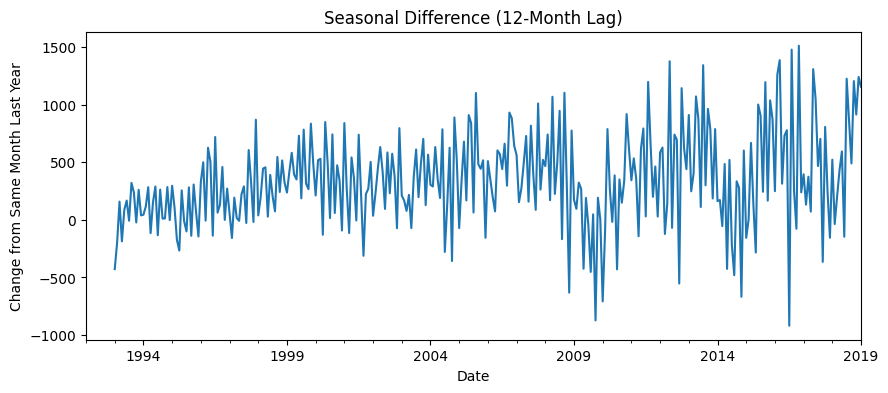

In [7]:
df["Seasonal_Diff"].plot(figsize=(10, 4), title="Seasonal Difference (12-Month Lag)")
plt.xlabel("Date")
plt.ylabel("Change from Same Month Last Year")
plt.show()


# 8) Summary

- The original time series showed a clear upward trend and strong seasonality.  
- The first differencing removed the long-term trend but kept seasonal patterns.  
- The seasonal differencing (lag = 12) further removed yearly seasonality, making the data more stationary.  
- These transformations are useful steps before applying time series models such as ARIMA.
**References:**
- GeeksforGeeks. *Python Pandas DataFrame shift()* — https://www.geeksforgeeks.org/python/python-pandas-dataframe-shift/  
- GeeksforGeeks. *Seasonal Adjustment and Differencing in Time Series* — https://www.geeksforgeeks.org/machine-learning/seasonal-adjustment-and-differencing-in-time-series/
